# CSE 144 Final Project - ViT Transfer Learning

**Task:** 100 class image classification using Vision Transformer (ViT-B/16) with ImageNet pretrained weights.  
**Dataset:** 100 classes, 10 training images per class, 1000 test images.  
**Strategy:** Fine tune a pretrained ViT with strong data augmentation to combat overfitting.

## 1. Setup and Imports

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models import ViT_B_16_Weights
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import copy

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device selection: MPS (Apple Silicon GPU) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: mps


## 2. Configuration

In [33]:
# --- PATHS (update these to match your system) ---
TRAIN_DIR = 'ucsc-cse-144-spring-2026-final-project/train'
TEST_DIR = 'ucsc-cse-144-spring-2026-final-project/test'
SAMPLE_CSV = 'ucsc-cse-144-spring-2026-final-project/sample_submission.csv'
MODEL_SAVE_PATH = 'best_vit_model.pth'

# --- HYPERPARAMETERS ---
NUM_CLASSES = 100
IMG_SIZE = 384          # SWAG weights use 384x384 (bigger = better features)
BATCH_SIZE = 16         # doubled from 8 - M4 has enough memory, 2x fewer batches
WEIGHT_DECAY = 0.02
LABEL_SMOOTHING = 0.1
VAL_SPLIT = 0.15
MIXUP_ALPHA = 0.3
DROPOUT = 0.4

# Phase 1: Train head only - converges fast, 5 epochs is enough
PHASE1_EPOCHS = 5
PHASE1_LR = 5e-4

# Phase 2: Fine-tune last 4 encoder blocks + head
PHASE2_EPOCHS = 15
PHASE2_BACKBONE_LR = 3e-6
PHASE2_HEAD_LR = 5e-5
PHASE2_PATIENCE = 5     # reduced from 8 - stop sooner if plateaued

# Phase 3: Retrain on ALL data (no val split)
PHASE3_EPOCHS = 10       # reduced from 15

## 3. Dataset Class

We build a custom dataset that:
- Reads images from folder per class structure
- Maps folder name (string) directly to integer label (folder "0" → label 0)
- Applies different transforms for train vs. validation

In [34]:
class TrainDataset(Dataset):
    """Dataset for training images organized in class folders."""
    def __init__(self, root_dir, transform=None):
        self.samples = []  # list of (image_path, label)
        self.transform = transform
        
        # Each subfolder name IS the class label (0-99)
        # Filter out hidden files like .DS_Store before sorting
        class_names = [d for d in os.listdir(root_dir) if not d.startswith('.') and os.path.isdir(os.path.join(root_dir, d))]
        class_names.sort(key=int)
        
        for class_name in class_names:
            class_dir = os.path.join(root_dir, class_name)
            label = int(class_name)  # folder "0" -> label 0
            for img_file in os.listdir(class_dir):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(class_dir, img_file), label))
        
        print(f'Loaded {len(self.samples)} training images across {len(class_names)} classes')
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


class TestDataset(Dataset):
    """Dataset for test images (no labels)."""
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.transform = transform
        # Sort numerically: 0.jpg, 1.jpg, ..., 999.jpg
        self.image_files = sorted(
            [f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))],
            key=lambda x: int(os.path.splitext(x)[0])
        )
        print(f'Loaded {len(self.image_files)} test images')
    
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.test_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_name

## 4. Data Augmentation + Mixup

With only ~10 images per class, strong augmentation is critical to prevent overfitting:
- **RandAugment**: learned augmentation policy (state-of-the-art)
- **RandomResizedCrop**: simulates scale/position variation
- **RandomHorizontalFlip**: doubles effective data
- **ColorJitter**: brightness, contrast, saturation, hue variations
- **RandomErasing**: acts as a regularizer (similar to Cutout)
- **Mixup**: blends pairs of images and labels for smoother decision boundaries

Validation/test transforms are deterministic (just resize + center crop + normalize).

In [35]:
# ImageNet normalization (required for pretrained ViT)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.RandAugment(num_ops=2, magnitude=9),  # strong learned augmentation
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

val_transform = T.Compose([
    T.Resize(int(IMG_SIZE * 1.05), interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Mixup: blends two images and their labels to create softer training targets
def mixup_data(x, y, alpha=0.2):
    """Apply mixup to a batch of images and labels."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute loss for mixup-blended targets."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print('Transforms + Mixup defined.')

Transforms + Mixup defined.


## 5. Create Datasets and DataLoaders

In [36]:
# Load full training set (with train augmentation initially)
full_dataset = TrainDataset(TRAIN_DIR, transform=None)  # transforms applied later per-split

# Split into train/val
total = len(full_dataset)
val_size = int(total * VAL_SPLIT)
train_size = total - val_size

torch.manual_seed(SEED)
train_indices, val_indices = random_split(range(total), [train_size, val_size])
train_indices = list(train_indices)
val_indices = list(val_indices)

print(f'Train: {len(train_indices)} images, Val: {len(val_indices)} images')

Loaded 1079 training images across 100 classes
Train: 918 images, Val: 161 images


In [37]:
class SubsetWithTransform(Dataset):
    """Wraps a subset of the base dataset with a specific transform."""
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        img_path, label = self.base_dataset.samples[self.indices[idx]]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


train_dataset = SubsetWithTransform(full_dataset, train_indices, train_transform)
val_dataset = SubsetWithTransform(full_dataset, val_indices, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Train batches: 58, Val batches: 11


## 6. Visualize Training Samples

/Users/satvik/Desktop/CSE144/venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


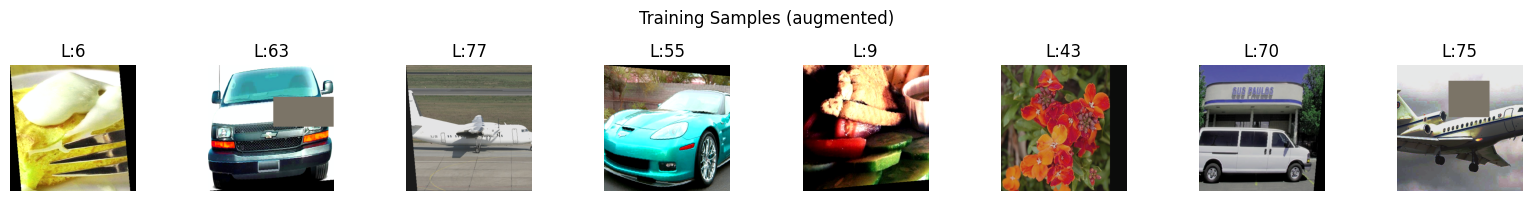

In [38]:
def show_batch(loader, n=8):
    """Display a batch of images from a dataloader."""
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]
    
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    for i in range(n):
        img = images[i].numpy().transpose(1, 2, 0)
        img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)  # unnormalize
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f'L:{labels[i].item()}')
        axes[i].axis('off')
    plt.suptitle('Training Samples (augmented)')
    plt.tight_layout()
    plt.show()

show_batch(train_loader)

## 7. Build ViT Model

**Key improvements for higher accuracy:**
1. **SWAG pretrained weights** - trained on 3.6B weakly supervised images, then fine tuned on ImageNet at 384x384. Much stronger than standard V1 weights (85.3% vs 81.1% top 1 on ImageNet).
2. **2-phase training**: Phase 1 trains only the classification head. Phase 2 unfreezes the last 6/12 encoder blocks with a much lower learning rate.
3. **Mixup** during training to smooth decision boundaries.
4. **Discriminative learning rates** - backbone gets 50x lower LR than the head.

In [39]:
def build_vit_model(num_classes, freeze_all_backbone=True):
    """
    Build a ViT-B/16 model with SWAG pretrained weights (384x384).
    
    freeze_all_backbone: if True, freeze everything except the head (for Phase 1).
    """
    # SWAG weights: trained on 3.6B weakly supervised images, fine tuned on ImageNet at 384x384
    weights = ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
    model = models.vit_b_16(weights=weights)
    
    if freeze_all_backbone:
        for param in model.parameters():
            param.requires_grad = False
    
    # Simple head - avoids overfitting with so few samples per class
    # The SWAG backbone already produces excellent 768 dim features
    in_features = model.heads.head.in_features  # 768
    model.heads.head = nn.Sequential(
        nn.Dropout(p=DROPOUT),
        nn.Linear(in_features, num_classes)
    )
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total params: {total_params:,}')
    print(f'Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)')
    
    return model


def unfreeze_last_n_blocks(model, n=4):
    """Unfreeze the last n encoder blocks for Phase 2 fine-tuning."""
    encoder_layers = model.encoder.layers
    num_layers = len(encoder_layers)
    
    for i, layer in enumerate(encoder_layers):
        if i >= num_layers - n:
            for param in layer.parameters():
                param.requires_grad = True
    
    # Also unfreeze the encoder layer norm
    for param in model.encoder.ln.parameters():
        param.requires_grad = True
    
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'After unfreezing last {n} blocks:')
    print(f'Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)')


# Phase 1: Build model with frozen backbone
print('=== Building model (Phase 1: head only) ===')
model = build_vit_model(NUM_CLASSES, freeze_all_backbone=True)
model = model.to(device)

=== Building model (Phase 1: head only) ===
Total params: 86,167,396
Trainable params: 76,900 (0.1%)


## 8. Training Functions

In [40]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

def train_one_epoch(model, loader, criterion, optimizer, device, use_mixup=True):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        if use_mixup and MIXUP_ALPHA > 0:
            images, targets_a, targets_b, lam = mixup_data(images, labels, MIXUP_ALPHA)
            outputs = model(images)
            loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
            # For accuracy tracking, use the dominant label
            _, predicted = outputs.max(1)
            correct += (lam * predicted.eq(targets_a).sum().item() +
                       (1 - lam) * predicted.eq(targets_b).sum().item())
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
    
    return running_loss / total, 100.0 * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / total, 100.0 * correct / total


def run_training_phase(model, train_loader, val_loader, optimizer, scheduler,
                       num_epochs, patience, phase_name, use_mixup=True):
    """Run a training phase and return history + best model state."""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    best_model_state = None
    patience_counter = 0
    
    print(f'\\n{"="*80}')
    print(f'{phase_name}: Training for up to {num_epochs} epochs (patience={patience})')
    print(f'{"="*80}')
    
    for epoch in range(num_epochs):
        current_lr = optimizer.param_groups[0]['lr']
        
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, use_mixup)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        if scheduler:
            scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        improved = ''
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, MODEL_SAVE_PATH)
            patience_counter = 0
            improved = ' *BEST*'
        else:
            patience_counter += 1
        
        print(f'Epoch [{epoch+1:2d}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.1f}% | '
              f'LR: {current_lr:.2e}{improved}')
        
        if patience_counter >= patience:
            print(f'Early stopping (no improvement for {patience} epochs)')
            break
    
    print(f'Best val accuracy this phase: {best_val_acc:.1f}%')
    # Restore best model
    model.load_state_dict(best_model_state)
    return history

print('Training functions defined.')

Training functions defined.


## 9. Two-Phase Training

**Phase 1** - Train only the classification head (backbone frozen). This lets the new head learn good features from the frozen SWAG backbone.

**Phase 2** - Unfreeze the last 6 encoder blocks and fine tune with discriminative learning rates (backbone LR = 50x lower than head LR). This adapts the transformer to our specific dataset without destroying the pretrained features.

In [41]:
# ===================== PHASE 1: Train head only =====================
optimizer_p1 = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR,
    weight_decay=WEIGHT_DECAY
)
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=PHASE1_EPOCHS, eta_min=1e-5)

history_p1 = run_training_phase(
    model, train_loader, val_loader, optimizer_p1, scheduler_p1,
    num_epochs=PHASE1_EPOCHS, patience=PHASE1_EPOCHS,  # no early stopping in phase 1
    phase_name='PHASE 1 (Head Only)', use_mixup=False  # no mixup for phase 1, small data
)

\n================================================================================
PHASE 1 (Head Only): Training for up to 5 epochs (patience=5)
Epoch [ 1/5] Train Loss: 4.2863 Acc: 9.9% | Val Loss: 3.1127 Acc: 27.3% | LR: 5.00e-04 *BEST*
Epoch [ 2/5] Train Loss: 2.8841 Acc: 36.5% | Val Loss: 2.4737 Acc: 43.5% | LR: 4.53e-04 *BEST*
Epoch [ 3/5] Train Loss: 2.3486 Acc: 51.2% | Val Loss: 2.1764 Acc: 50.3% | LR: 3.31e-04 *BEST*
Epoch [ 4/5] Train Loss: 2.1511 Acc: 56.4% | Val Loss: 2.0770 Acc: 54.0% | LR: 1.79e-04 *BEST*
Epoch [ 5/5] Train Loss: 2.0444 Acc: 61.2% | Val Loss: 2.0558 Acc: 56.5% | LR: 5.68e-05 *BEST*
Best val accuracy this phase: 56.5%


In [ ]:
# ===================== PHASE 2: Fine tune backbone + head =====================
print('\nUnfreezing last 4 encoder blocks...')
unfreeze_last_n_blocks(model, n=4)

# Discriminative learning rates: backbone gets much lower LR
backbone_params = []
head_params = []
for name, param in model.named_parameters():
    if param.requires_grad:
        if 'heads' in name:
            head_params.append(param)
        else:
            backbone_params.append(param)

optimizer_p2 = optim.AdamW([
    {'params': backbone_params, 'lr': PHASE2_BACKBONE_LR},
    {'params': head_params, 'lr': PHASE2_HEAD_LR},
], weight_decay=WEIGHT_DECAY)

scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=PHASE2_EPOCHS, eta_min=1e-7)

history_p2 = run_training_phase(
    model, train_loader, val_loader, optimizer_p2, scheduler_p2,
    num_epochs=PHASE2_EPOCHS, patience=PHASE2_PATIENCE,
    phase_name='PHASE 2 (Fine-tune Last 4 Blocks + Head)', use_mixup=True
)

# Combine histories for plotting
history = {k: history_p1[k] + history_p2[k] for k in history_p1}
print(f'\nPhase 1+2 complete. Best val accuracy: {max(history["val_acc"]):.1f}%')


Unfreezing last 4 encoder blocks...
After unfreezing last 4 blocks:
Trainable params: 28,429,924 (33.0%)
\n================================================================================
PHASE 2 (Fine-tune Last 4 Blocks + Head): Training for up to 15 epochs (patience=5)
Epoch [ 1/15] Train Loss: 2.5059 Acc: 49.8% | Val Loss: 1.9827 Acc: 59.0% | LR: 3.00e-06 *BEST*
Epoch [ 2/15] Train Loss: 2.3441 Acc: 52.0% | Val Loss: 1.9081 Acc: 64.0% | LR: 2.97e-06 *BEST*
Epoch [ 3/15] Train Loss: 2.4059 Acc: 53.1% | Val Loss: 1.8676 Acc: 65.8% | LR: 2.87e-06 *BEST*
Epoch [ 4/15] Train Loss: 2.2968 Acc: 57.6% | Val Loss: 1.8121 Acc: 66.5% | LR: 2.72e-06 *BEST*
Epoch [ 5/15] Train Loss: 2.2964 Acc: 56.0% | Val Loss: 1.7903 Acc: 66.5% | LR: 2.52e-06
Epoch [ 6/15] Train Loss: 2.1525 Acc: 61.8% | Val Loss: 1.7616 Acc: 67.1% | LR: 2.28e-06 *BEST*
Epoch [ 7/15] Train Loss: 2.1711 Acc: 61.2% | Val Loss: 1.7339 Acc: 68.3% | LR: 2.00e-06 *BEST*
Epoch [ 8/15] Train Loss: 2.0909 Acc: 65.4% | Val Loss: 1.7390

## 10. Plot Training Curves

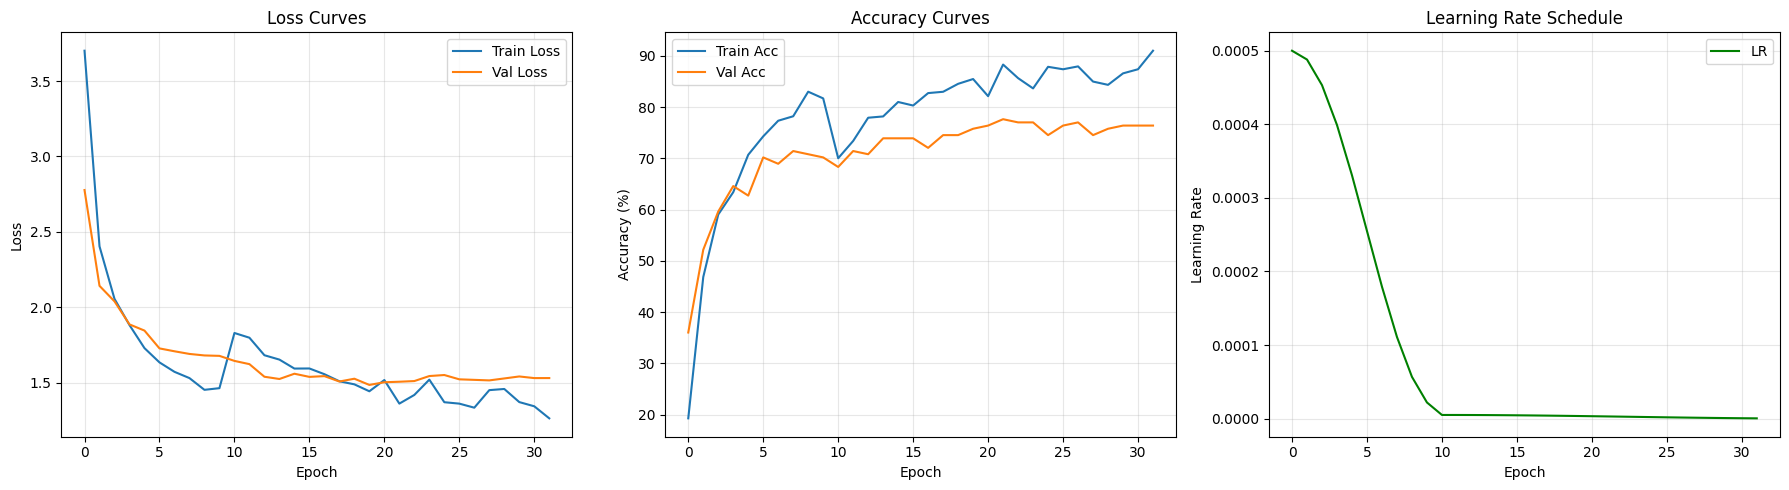

Saved training_curves.png


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning Rate
axes[2].plot(history['lr'], label='LR', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

## 11. Phase 3 - Retrain on ALL Data for Final Submission

For Kaggle competitions, every training sample matters. Now that we've validated our approach with a val split, we retrain the model from scratch on **all 1079 images** using the same hyperparameters. This gives ~15% more training data, which is significant when you only have 10 images per class.

In [43]:
# ===================== PHASE 3: Retrain on ALL data =====================
# Build a fresh model and train on all 1079 images (no validation holdout)
# This maximizes the data the model sees before generating Kaggle predictions

print('=== PHASE 3: Retraining on ALL data ===')
model_final = build_vit_model(NUM_CLASSES, freeze_all_backbone=True)
model_final = model_final.to(device)

# Full dataset with train augmentation
full_train_dataset = SubsetWithTransform(full_dataset, list(range(len(full_dataset))), train_transform)
full_train_loader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
print(f'Full training set: {len(full_train_dataset)} images, {len(full_train_loader)} batches')

# --- Phase 3a: Head only (same as Phase 1) ---
optimizer_3a = optim.AdamW(
    filter(lambda p: p.requires_grad, model_final.parameters()),
    lr=PHASE1_LR, weight_decay=WEIGHT_DECAY
)
scheduler_3a = optim.lr_scheduler.CosineAnnealingLR(optimizer_3a, T_max=PHASE1_EPOCHS, eta_min=1e-5)

print(f'\nPhase 3a: Head only for {PHASE1_EPOCHS} epochs...')
for epoch in range(PHASE1_EPOCHS):
    train_loss, train_acc = train_one_epoch(model_final, full_train_loader, criterion, optimizer_3a, device, use_mixup=False)
    scheduler_3a.step()
    lr = optimizer_3a.param_groups[0]['lr']
    print(f'  Epoch [{epoch+1:2d}/{PHASE1_EPOCHS}] Loss: {train_loss:.4f} Acc: {train_acc:.1f}% LR: {lr:.2e}')

# --- Phase 3b: Unfreeze last 4 blocks (same as Phase 2) ---
print(f'\nPhase 3b: Unfreezing last 4 blocks for {PHASE3_EPOCHS} epochs...')
unfreeze_last_n_blocks(model_final, n=4)

backbone_params_3 = []
head_params_3 = []
for name, param in model_final.named_parameters():
    if param.requires_grad:
        if 'heads' in name:
            head_params_3.append(param)
        else:
            backbone_params_3.append(param)

optimizer_3b = optim.AdamW([
    {'params': backbone_params_3, 'lr': PHASE2_BACKBONE_LR},
    {'params': head_params_3, 'lr': PHASE2_HEAD_LR},
], weight_decay=WEIGHT_DECAY)
scheduler_3b = optim.lr_scheduler.CosineAnnealingLR(optimizer_3b, T_max=PHASE3_EPOCHS, eta_min=1e-7)

for epoch in range(PHASE3_EPOCHS):
    train_loss, train_acc = train_one_epoch(model_final, full_train_loader, criterion, optimizer_3b, device, use_mixup=True)
    scheduler_3b.step()
    lr = optimizer_3b.param_groups[0]['lr']
    print(f'  Epoch [{epoch+1:2d}/{PHASE3_EPOCHS}] Loss: {train_loss:.4f} Acc: {train_acc:.1f}% LR: {lr:.2e}')

# Save the final model
torch.save(model_final.state_dict(), MODEL_SAVE_PATH)
print(f'\nFinal model saved to {MODEL_SAVE_PATH}')
# Use the final model for inference
model = model_final

=== PHASE 3: Retraining on ALL data ===
Total params: 86,167,396
Trainable params: 76,900 (0.1%)
Full training set: 1079 images, 68 batches

Phase 3a: Head only for 5 epochs...
  Epoch [ 1/5] Loss: 4.1072 Acc: 11.4% LR: 4.53e-04
  Epoch [ 2/5] Loss: 2.7556 Acc: 37.1% LR: 3.31e-04
  Epoch [ 3/5] Loss: 2.2892 Acc: 51.0% LR: 1.79e-04
  Epoch [ 4/5] Loss: 2.0549 Acc: 60.2% LR: 5.68e-05
  Epoch [ 5/5] Loss: 2.0047 Acc: 62.0% LR: 1.00e-05

Phase 3b: Unfreezing last 4 blocks for 10 epochs...
After unfreezing last 4 blocks:
Trainable params: 28,429,924 (33.0%)
  Epoch [ 1/10] Loss: 2.5061 Acc: 50.6% LR: 2.93e-06
  Epoch [ 2/10] Loss: 2.4181 Acc: 54.2% LR: 2.72e-06
  Epoch [ 3/10] Loss: 2.3763 Acc: 55.2% LR: 2.40e-06
  Epoch [ 4/10] Loss: 2.2288 Acc: 59.9% LR: 2.00e-06
  Epoch [ 5/10] Loss: 2.2522 Acc: 59.8% LR: 1.55e-06
  Epoch [ 6/10] Loss: 2.2321 Acc: 61.8% LR: 1.10e-06
  Epoch [ 7/10] Loss: 2.1189 Acc: 63.7% LR: 6.98e-07
  Epoch [ 8/10] Loss: 2.1268 Acc: 64.8% LR: 3.77e-07
  Epoch [ 9/10] L

## 12. Generate Test Predictions with Test Time Augmentation (TTA)

TTA averages predictions from multiple augmented views of each test image, producing more robust predictions. We use 10 augmented views per image.

In [52]:
# Load the best model
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
model.eval()
print('Loaded best model for inference.')

# TTA transforms: multiple augmented views per test image
tta_transforms = [
    val_transform,  # standard center crop (always included)
    T.Compose([T.Resize(int(IMG_SIZE * 1.05), interpolation=T.InterpolationMode.BICUBIC),
               T.CenterCrop(IMG_SIZE), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), interpolation=T.InterpolationMode.BICUBIC),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0), interpolation=T.InterpolationMode.BICUBIC),
               T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize(int(IMG_SIZE * 1.15), interpolation=T.InterpolationMode.BICUBIC),
               T.CenterCrop(IMG_SIZE),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize(int(IMG_SIZE * 1.15), interpolation=T.InterpolationMode.BICUBIC),
               T.CenterCrop(IMG_SIZE), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.Resize(int(IMG_SIZE * 1.25), interpolation=T.InterpolationMode.BICUBIC),
               T.CenterCrop(IMG_SIZE),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), interpolation=T.InterpolationMode.BICUBIC),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), interpolation=T.InterpolationMode.BICUBIC),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    T.Compose([T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), interpolation=T.InterpolationMode.BICUBIC),
               T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]

print(f'Using {len(tta_transforms)} TTA views per test image.')

# Accumulate soft predictions (logits) across all TTA views
all_logits = {}  # filename -> summed logits

for t_idx, tta_tf in enumerate(tta_transforms):
    test_dataset = TestDataset(TEST_DIR, transform=tta_tf)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    with torch.no_grad():
        for images, filenames in test_loader:
            images = images.to(device)
            outputs = model(images)  # logits
            
            for fname, logit in zip(filenames, outputs.cpu()):
                if fname not in all_logits:
                    all_logits[fname] = logit
                else:
                    all_logits[fname] += logit
    
    print(f'  TTA view {t_idx+1}/{len(tta_transforms)} done.')

# Final predictions: argmax of averaged logits
predictions = {fname: int(logits.argmax()) for fname, logits in all_logits.items()}
print(f'\\nGenerated TTA predictions for {len(predictions)} test images.')

Loaded best model for inference.
Using 10 TTA views per test image.
Loaded 1036 test images
  TTA view 1/10 done.
Loaded 1036 test images
  TTA view 2/10 done.
Loaded 1036 test images
  TTA view 3/10 done.
Loaded 1036 test images
  TTA view 4/10 done.
Loaded 1036 test images
  TTA view 5/10 done.
Loaded 1036 test images
  TTA view 6/10 done.
Loaded 1036 test images
  TTA view 7/10 done.
Loaded 1036 test images
  TTA view 8/10 done.
Loaded 1036 test images
  TTA view 9/10 done.
Loaded 1036 test images
  TTA view 10/10 done.
\nGenerated TTA predictions for 1036 test images.


In [53]:
# Build submission CSV directly from all predictions (not filtered through sample_submission.csv)
rows = [{'ID': fname, 'Label': label} for fname, label in predictions.items()]
submission_df = pd.DataFrame(rows)
# Sort by numeric filename so rows are in order: 0.jpg, 1.jpg, ..., 1035.jpg
submission_df['_sort'] = submission_df['ID'].apply(lambda x: int(os.path.splitext(x)[0]))
submission_df = submission_df.sort_values('_sort').drop(columns='_sort').reset_index(drop=True)

submission_df.to_csv('submission.csv', index=False)
print(f'Saved submission.csv with {len(submission_df)} rows')
print(submission_df.head(10))
print(f'\nLabel distribution (first 10 classes):')
print(submission_df['Label'].value_counts().sort_index().head(10))

Saved submission.csv with 1036 rows
      ID  Label
0  0.jpg     62
1  1.jpg     43
2  2.jpg     38
3  3.jpg     51
4  4.jpg     42
5  5.jpg     89
6  6.jpg      3
7  7.jpg     28
8  8.jpg     72
9  9.jpg     65

Label distribution (first 10 classes):
Label
0     4
1    13
2    11
3    11
4     9
5     8
6     8
7     9
8    16
9    10
Name: count, dtype: int64


## 13. Verify Model Can Be Loaded for Reproducibility

In [54]:
# Demonstrate that the saved model can be loaded and used for inference
def load_and_predict(model_path, test_dir, device):
    """Standalone inference function for reproducibility."""
    # Rebuild model architecture (must match training architecture exactly)
    weights = ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
    model = models.vit_b_16(weights=weights)
    in_features = model.heads.head.in_features
    model.heads.head = nn.Sequential(
        nn.Dropout(p=DROPOUT),
        nn.Linear(in_features, 100)
    )
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model = model.to(device)
    model.eval()
    
    transform = T.Compose([
        T.Resize(int(384 * 1.05), interpolation=T.InterpolationMode.BICUBIC),
        T.CenterCrop(384),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    test_ds = TestDataset(test_dir, transform=transform)
    test_dl = DataLoader(test_ds, batch_size=8, shuffle=False)
    
    preds = {}
    with torch.no_grad():
        for imgs, fnames in test_dl:
            imgs = imgs.to(device)
            out = model(imgs)
            _, p = out.max(1)
            for fn, pr in zip(fnames, p.cpu().numpy()):
                preds[fn] = int(pr)
    
    rows = [{'ID': fname, 'Label': label} for fname, label in preds.items()]
    df = pd.DataFrame(rows)
    df['_sort'] = df['ID'].apply(lambda x: int(os.path.splitext(x)[0]))
    df = df.sort_values('_sort').drop(columns='_sort').reset_index(drop=True)
    return df

# Quick verification (without TTA - just center crop)
verify_df = load_and_predict(MODEL_SAVE_PATH, TEST_DIR, device)
print(f'Reproducibility check: loaded model generates {len(verify_df)} predictions')

Loaded 1036 test images
Reproducibility check: loaded model generates 1036 predictions


---
## Summary

| Component | Choice | Rationale |
|-----------|--------|----------|
| **Model** | ViT-B/16 | Strong pretrained features, excellent for transfer learning |
| **Pretrained weights** | IMAGENET1K_SWAG_E2E_V1 (384x384) | SWAG trained on 3.6B images, 85.3% ImageNet top-1 |
| **Image size** | 384x384 | Matches SWAG pretraining resolution |
| **Training** | 3-phase | Phase 1: head only → Phase 2: unfreeze last 4/12 blocks (with val) → Phase 3: retrain on ALL data |
| **Head** | Dropout(0.4) → Linear(768, 100) | Simple head to prevent overfitting with ~10 img/class |
| **Optimizer** | AdamW with discriminative LRs | Backbone LR = 3e-6, Head LR = 5e-5 |
| **Scheduler** | CosineAnnealingLR | Smooth LR decay per phase |
| **Loss** | CrossEntropy + label smoothing (0.1) | Prevents overconfident predictions |
| **Augmentation** | RandAugment + crop + flip + color jitter + erasing | State-of-the-art augmentation pipeline |
| **Mixup** | alpha=0.3 (Phase 2/3 fine-tuning only) | Smooths decision boundaries |
| **Weight decay** | 0.02 | Stronger L2 regularization |
| **Gradient clipping** | max_norm=1.0 | Stabilizes training |
| **Inference** | 10-view Test-Time Augmentation (TTA) | Averages predictions over multiple augmented views |
| **Early stopping** | Patience = 8 epochs (Phase 2) | Stops before severe overfitting |